# CB (Circuit Breaker) Trafo Temperature Forecasting

Notebook prediktif untuk memperkirakan suhu Circuit Breaker (CB) pada sisi incoming trafo (anonim), menggunakan `HistGradientBoostingRegressor`. Output berupa forecast 1 tahun ke depan beserta status early-warning (Monitoring/Warning/Critical/Maintenance) berdasarkan threshold 60/65/68/70°C.

## 1. Load Data & Preprocessing
Memuat data sensor suhu CB dari `sensorsuhu.xlsx`, membersihkan nilai tidak valid, dan melakukan resampling per jam.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

file_path = "sensorsuhu.xlsx"

df = pd.read_excel(file_path)

time_col = "MCGS_TIME"

temp_cols = [
    "R ATAS INC TRF 3",
    "S ATAS INC TRF 3",
    "T ATAS INC TRF 3",
    "R BAWAH INC TRF 3",
    "S BAWAH INC TRF 3",
    "T BAWAH INC TRF 3"
]

df[time_col] = pd.to_datetime(df[time_col])

for col in temp_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df.loc[df[col] <= 0, col] = np.nan

df = (
    df.sort_values(time_col)
      .drop_duplicates(time_col)
      .set_index(time_col)
)

df = df[temp_cols].resample("1h").mean()
df = df.interpolate(method="time", limit=3)
df = df.dropna()

df["TMAX"] = df[temp_cols].max(axis=1)

## 2. Feature Engineering
Membuat fitur kalender (siklus waktu), lag, dan rolling statistics dari suhu historis (TMAX).

In [2]:
def create_features(index):

    x = pd.DataFrame(index=index)

    hour = index.hour
    dow = index.dayofweek
    doy = index.dayofyear
    month = index.month

    x["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    x["hour_cos"] = np.cos(2 * np.pi * hour / 24)

    x["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    x["dow_cos"] = np.cos(2 * np.pi * dow / 7)

    x["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    x["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    x["doy_sin_2"] = np.sin(4 * np.pi * doy / 365.25)
    x["doy_cos_2"] = np.cos(4 * np.pi * doy / 365.25)

    x["month"] = month
    x["hour"] = hour
    x["day_of_week"] = dow

    return x

X_calendar = create_features(df.index)

df["LAG_24H"] = df["TMAX"].shift(24)
df["LAG_48H"] = df["TMAX"].shift(48)
df["LAG_7D"] = df["TMAX"].shift(24 * 7)

df["MEAN_24H"] = df["TMAX"].rolling(24).mean()
df["STD_24H"] = df["TMAX"].rolling(24).std()

df["MEAN_7D"] = df["TMAX"].rolling(24 * 7).mean()
df["STD_7D"] = df["TMAX"].rolling(24 * 7).std()

features = pd.concat([
    X_calendar,
    df[
        [
            "LAG_24H",
            "LAG_48H",
            "LAG_7D",
            "MEAN_24H",
            "STD_24H",
            "MEAN_7D",
            "STD_7D"
        ]
    ]
], axis=1)

data = features.copy()
data["TARGET"] = df["TMAX"]

data = data.dropna()

## 3. Train & Evaluate Model
Melatih model `HistGradientBoostingRegressor` dengan split time-series (80/20) dan mengevaluasi performa (MAE, RMSE, R²).

In [3]:
split = int(len(data) * 0.8)

X_train = data.iloc[:split].drop(columns="TARGET")
y_train = data.iloc[:split]["TARGET"]

X_test = data.iloc[split:].drop(columns="TARGET")
y_test = data.iloc[split:]["TARGET"]

model = HistGradientBoostingRegressor(
    learning_rate=0.04,
    max_iter=400,
    max_leaf_nodes=31,
    l2_regularization=3,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)
print(f"MAE  : {mae:.3f} °C")
print(f"RMSE : {rmse:.3f} °C")
print(f"R²   : {r2:.3f}")

MODEL EVALUATION
MAE  : 0.575 °C
RMSE : 0.717 °C
R²   : 0.904


## 4. One-Year Forecast (Seasonal Model)
Melatih model musiman menggunakan seluruh data historis untuk menghasilkan forecast 1 tahun ke depan.

In [4]:
# Seasonal model for long-term forecasting

seasonal_features = create_features(df.index)

seasonal_data = seasonal_features.copy()
seasonal_data["TARGET"] = df["TMAX"]

seasonal_data = seasonal_data.dropna()

seasonal_model = HistGradientBoostingRegressor(
    learning_rate=0.04,
    max_iter=500,
    max_leaf_nodes=31,
    l2_regularization=3,
    random_state=42
)

seasonal_model.fit(
    seasonal_data.drop(columns="TARGET"),
    seasonal_data["TARGET"]
)

last_time = df.index[-1]

forecast_end = last_time + pd.Timedelta(days=365)

future_index = pd.date_range(
    start=last_time + pd.Timedelta(hours=1),
    end=forecast_end,
    freq="1h"
)

future_features = create_features(
    future_index
)

future_prediction = seasonal_model.predict(
    future_features
)

forecast = pd.DataFrame(
    {
        "Datetime": future_index,
        "Predicted_TMAX": future_prediction
    }
)

forecast["Status"] = np.select(
    [
        forecast["Predicted_TMAX"] >= 70,
        forecast["Predicted_TMAX"] >= 68,
        forecast["Predicted_TMAX"] >= 65,
        forecast["Predicted_TMAX"] >= 60
    ],
    [
        "MAINTENANCE",
        "CRITICAL",
        "WARNING",
        "MONITORING"
    ],
    default="NORMAL"
)

## 5. Threshold Analysis & Early-Warning Status
Menganalisis kapan suhu forecast melewati threshold (60/65/68/70°C), hari-hari berisiko tinggi, dan ringkasan bulanan.

In [9]:
print("\nONE-YEAR THRESHOLD FORECAST\n")

for threshold in [60, 65, 68, 70]:

    temp = forecast[
        forecast["Predicted_TMAX"] >= threshold
    ]

    print(f"\nThreshold {threshold}°C")

    if len(temp) == 0:
        print("Tidak diprediksi tercapai.")

    else:
        print(
            f"First occurrence : "
            f"{temp.iloc[0]['Datetime']}"
        )

        print(
            f"Maximum forecast : "
            f"{temp['Predicted_TMAX'].max():.2f}°C"
        )

near_70 = forecast[
    forecast["Predicted_TMAX"] >= 65
].copy()

near_70["Distance_70"] = abs(
    near_70["Predicted_TMAX"] - 70
)

near_70 = near_70.sort_values(
    "Distance_70"
)

print("\nTOP PREDICTIONS NEAR 70°C\n")

print(
    near_70[
        [
            "Datetime",
            "Predicted_TMAX",
            "Status"
        ]
    ].head(30).to_string(index=False)
)

daily_forecast = (
    forecast
    .set_index("Datetime")
    .resample("1D")["Predicted_TMAX"]
    .max()
    .reset_index()
)

daily_forecast["Status"] = np.select(
    [
        daily_forecast["Predicted_TMAX"] >= 70,
        daily_forecast["Predicted_TMAX"] >= 68,
        daily_forecast["Predicted_TMAX"] >= 65,
        daily_forecast["Predicted_TMAX"] >= 60
    ],
    [
        "MAINTENANCE",
        "CRITICAL",
        "WARNING",
        "MONITORING"
    ],
    default="NORMAL"
)

print("\nPREDICTED HIGH-RISK DAYS\n")

print(
    daily_forecast[
        daily_forecast["Predicted_TMAX"] >= 65
    ].to_string(index=False)
)

monthly_forecast = (
    forecast
    .set_index("Datetime")["Predicted_TMAX"]
    .resample("ME")
    .agg(["mean", "max"])
    .reset_index()
)

monthly_forecast.columns = [
    "Month",
    "Mean_Temperature",
    "Maximum_Temperature"
]

print("\n" + "=" * 60)
print("MONTHLY FORECAST")
print("=" * 60)

print(
    monthly_forecast.to_string(index=False)
)


ONE-YEAR THRESHOLD FORECAST


Threshold 60°C
First occurrence : 2026-10-07 19:00:00
Maximum forecast : 66.01°C

Threshold 65°C
First occurrence : 2027-04-21 18:00:00
Maximum forecast : 66.01°C

Threshold 68°C
Tidak diprediksi tercapai.

Threshold 70°C
Tidak diprediksi tercapai.

TOP PREDICTIONS NEAR 70°C

           Datetime  Predicted_TMAX  Status
2027-04-23 19:00:00       66.009461 WARNING
2027-04-23 20:00:00       65.886782 WARNING
2027-04-23 21:00:00       65.674002 WARNING
2027-04-22 19:00:00       65.395934 WARNING
2027-04-23 18:00:00       65.375899 WARNING
2027-04-21 19:00:00       65.324598 WARNING
2027-04-22 20:00:00       65.207440 WARNING
2027-04-21 18:00:00       65.097440 WARNING
2027-04-21 20:00:00       65.076505 WARNING

PREDICTED HIGH-RISK DAYS

  Datetime  Predicted_TMAX  Status
2027-04-21       65.324598 WARNING
2027-04-22       65.395934 WARNING
2027-04-23       66.009461 WARNING

MONTHLY FORECAST
     Month  Mean_Temperature  Maximum_Temperature
2026-08-31       

## 6. Visualization
Memvisualisasikan data historis vs forecast, serta tren maksimum bulanan terhadap threshold.

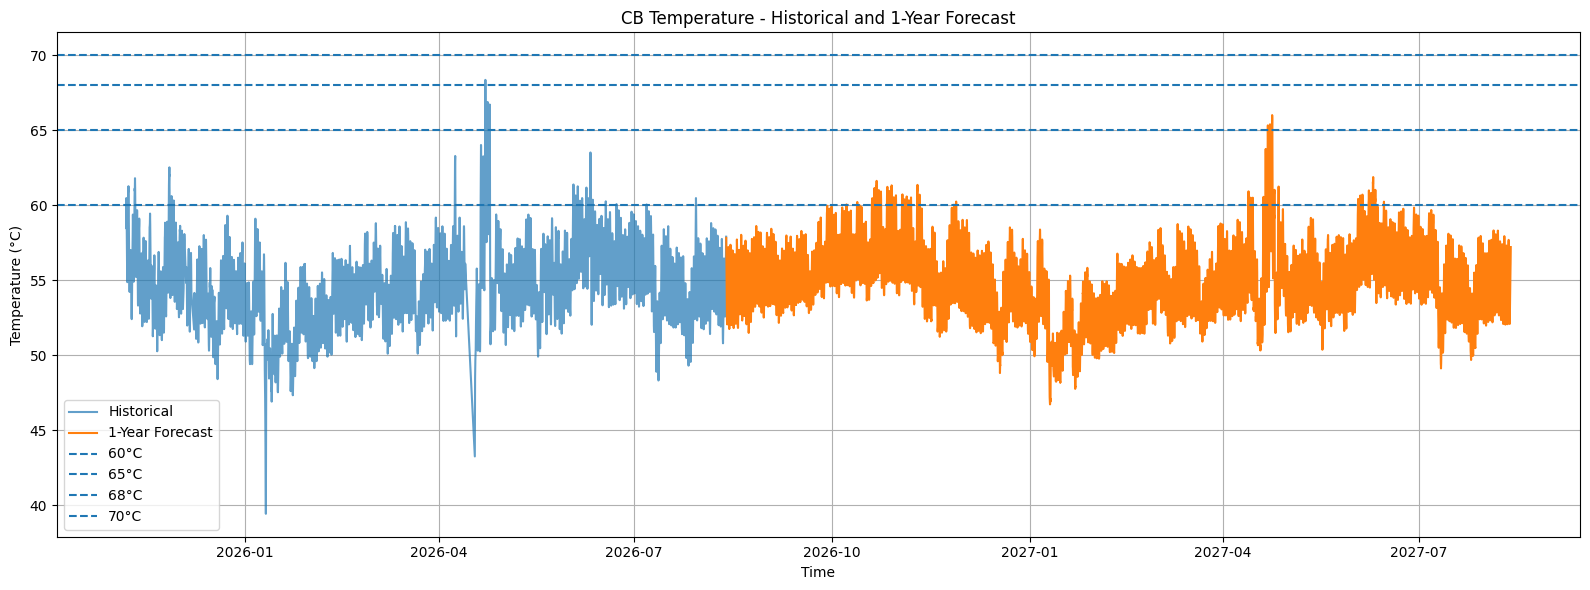

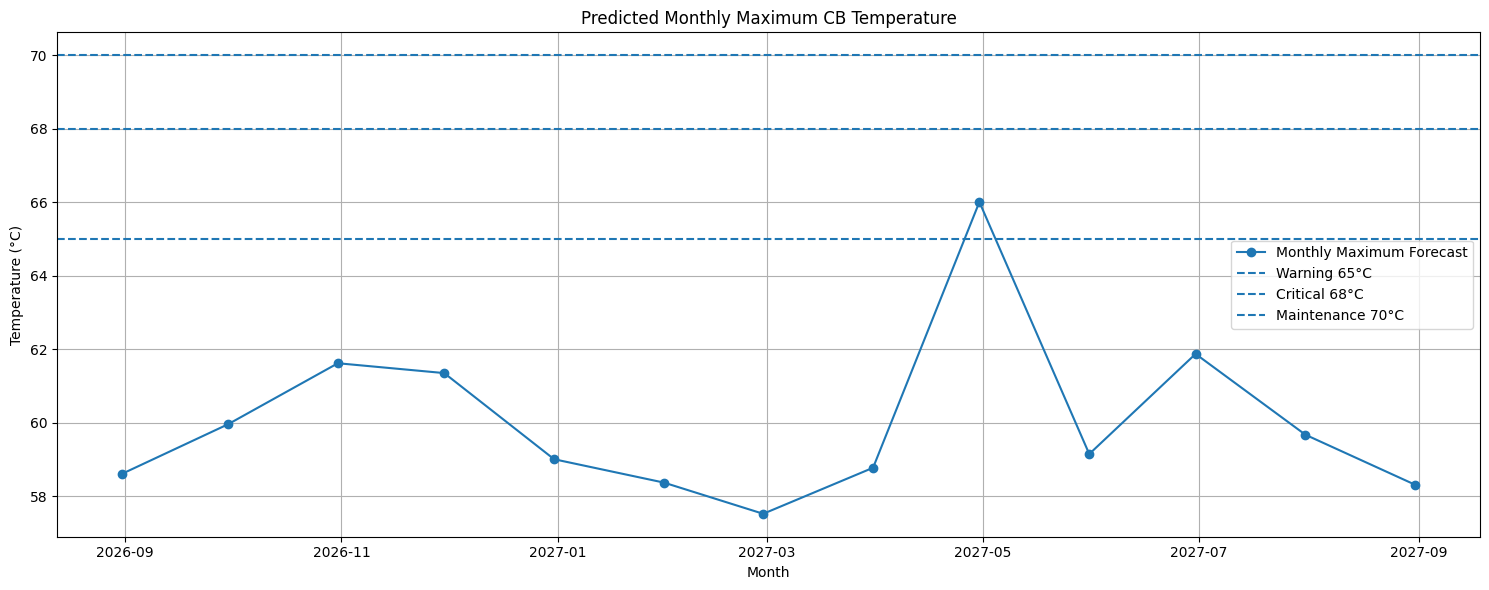

In [6]:
plt.figure(figsize=(16, 6))

plt.plot(
    df.index,
    df["TMAX"],
    label="Historical",
    alpha=0.7
)

plt.plot(
    forecast["Datetime"],
    forecast["Predicted_TMAX"],
    label="1-Year Forecast"
)

for threshold in [60, 65, 68, 70]:

    plt.axhline(
        threshold,
        linestyle="--",
        label=f"{threshold}°C"
    )

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title(
    "CB Temperature - Historical and 1-Year Forecast"
)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_forecast["Month"],
    monthly_forecast["Maximum_Temperature"],
    marker="o",
    label="Monthly Maximum Forecast"
)

plt.axhline(
    65,
    linestyle="--",
    label="Warning 65°C"
)

plt.axhline(
    68,
    linestyle="--",
    label="Critical 68°C"
)

plt.axhline(
    70,
    linestyle="--",
    label="Maintenance 70°C"
)

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Predicted Monthly Maximum CB Temperature")

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## 7. Export Forecast Results
Mengekspor hasil forecast (per jam, harian, bulanan) ke file Excel.

In [7]:
forecast.to_excel(
    "CB_1_Year_Forecast.xlsx",
    index=False
)

daily_forecast.to_excel(
    "CB_Daily_Forecast.xlsx",
    index=False
)

monthly_forecast.to_excel(
    "CB_Monthly_Forecast.xlsx",
    index=False
)